# Self-Attention Models: Fundamentals

## Introduction

Self-attention is the core mechanism behind modern Transformer architectures and large language models (LLMs) such as GPT, BERT, and many multimodal AI systems. Understanding self-attention is a crucial step toward understanding how these models process language, reason about context, and capture relationships between tokens in a sequence.

The goal of this notebook is to build an intuitive and mathematical understanding of self-attention from first principles. Rather than treating the attention mechanism as a black box, we will explore how it works step-by-step using simple examples and NumPy implementations.

Throughout this notebook, we will answer the following questions:

* Why were attention mechanisms introduced?
* What limitations of recurrent neural networks (RNNs) does attention address?
* How can a model determine which words are relevant to each other?
* What are Query, Key, and Value vectors?
* How are attention scores calculated?
* Why do we use the Softmax function?
* Why is attention scaled by √dₖ?
* How does self-attention produce context-aware representations?

By the end of this notebook, you should be able to:

* Explain the intuition behind self-attention.
* Compute attention scores manually.
* Understand the role of dot products and similarity measures.
* Interpret attention matrices and heatmaps.
* Understand the purpose of Query, Key, and Value projections.
* Derive and explain the scaled dot-product attention formula.

This notebook focuses on the conceptual and mathematical foundations of self-attention. In the [next notebook](https://github.com/Maxstef/data-loves-ml-for-people-course/blob/main/notebooks/4_3_dl_sequence_modeling/0_5_self_attention_scratch.ipynb), we will implement self-attention from scratch and build reusable attention modules similar to those used in modern deep learning frameworks.


# Section 1 - Why Do We Need Attention?

## Learning Objectives

After completing this section, you should be able to:

* Explain the limitations of traditional sequence models.
* Understand what "long-range dependency" means.
* Explain why compressing an entire sentence into a single vector is problematic.
* Understand the intuition behind attention as "selective focus."

---

## 1.1 The Sequence Modeling Problem

Many machine learning tasks involve sequences:

* Natural language
* Speech
* Time series
* DNA sequences

For example:

```text
I love machine learning
```

A model must understand that:

* words appear in a specific order
* words influence each other
* meaning depends on context

Historically, this was handled using Recurrent Neural Networks (RNNs).

---

## 1.2 How RNNs Process Sequences

An RNN processes tokens one at a time.

```text
I      → h1
love   → h2
machine→ h3
learning→ h4
```

where:

* `h1` remembers information from "I"
* `h2` remembers information from "I love"
* `h3` remembers information from "I love machine"
* etc.

Conceptually:

```text
token_t + previous_state
            ↓
       new_state
```

The hidden state acts like a running summary of everything seen so far.

---

### Simple Demonstration

Let's create a toy example.

Imagine reading a sentence word by word:

The variable `memory` is similar to an RNN hidden state:

* it accumulates information
* it becomes increasingly responsible for storing everything

---

In [1]:
sentence = ["I", "love", "machine", "learning"]

memory = ""

for word in sentence:
    memory += " " + word
    print(memory)

 I
 I love
 I love machine
 I love machine learning



## 1.3 The Bottleneck Problem

Consider:

```text
The cat sat on the mat.
```

Compressing this sentence into one vector is manageable.

Now consider:

```text
The cat that lived in the old house near the river and often chased birds sat on the mat.
```

Much harder.

Now imagine:

* 100 words
* 500 words
* 2000 words

The model is still expected to compress everything into a fixed-size representation.

This creates an information bottleneck.

---

### Analogy

Suppose you read a 300-page book and then are allowed to keep only one sticky note containing the summary.

Later someone asks:

> What was the name of the detective introduced on page 7?

The information may be lost.

Traditional encoder-decoder architectures suffered from a similar problem.

---

## 1.4 Long-Range Dependencies

Consider:

```text
The animal didn't cross the road because it was tired.
```

Question:

> What does "it" refer to?

Answer:

```text
The animal
```

The words are separated by several tokens.

Now a harder example:

```text
The animal that had been walking all day through the forest didn't cross the road because it was tired.
```

The model must connect:

```text
animal  ←→  it
```

despite many intervening words.

This is called a **long-range dependency**.

---

### Another Example

```text
The keys to the cabinet are on the table.
```

The verb:

```text
are
```

depends on:

```text
keys
```

not:

```text
cabinet
```

A model must remember the correct relationship across distance.

---

## 1.5 Why RNNs Struggle

Information from earlier tokens must travel through many recurrent steps.

Conceptually:

```text
word1 → h1
          ↓
word2 → h2
          ↓
word3 → h3
          ↓
...
          ↓
word100 → h100
```

If token 100 needs information from token 1:

```text
token1 → token2 → token3 → ... → token100
```

the signal must pass through 99 transformations.

Important information can become weakened or distorted.

This is related to the **vanishing gradient problem**, though attention addresses more than just that issue.

---

## 1.6 The Key Idea Behind Attention

Instead of forcing information to travel through every intermediate step:

```text
token1 → token2 → token3 → ... → token100
```

allow a direct lookup:

```text
token100 ─────────────► token1
```

When processing a word, the model can ask:

> Which words are relevant to me right now?

For example:

```text
The animal didn't cross the road because it was tired.
```

When processing:

```text
it
```

the model may directly focus on:

```text
animal
```

rather than relying on a long chain of memory.

This is the core intuition of attention.

---

## Key Takeaways

* RNNs process sequences sequentially.
* Hidden states act as compressed memory.
* Long sequences create information bottlenecks.
* Important relationships may span many tokens.
* Attention allows direct access to relevant tokens.
* Instead of remembering everything equally, the model learns where to focus.

---


# Section 2 - Intuition Behind Self-Attention

## Learning Objectives

After this section, you should be able to:

* Explain self-attention in plain language.
* Understand attention as a weighted information lookup.
* Read and interpret an attention matrix.
* Understand why different words attend to different words.
* Build a simple attention mechanism manually.

---

## 2.1 What Does "Attention" Mean?

Suppose we're processing the sentence:

```text
The cat sat on the mat
```

When a human reads the word:

```text
sat
```

they naturally associate it with:

```text
cat
```

because:

> Cats are things that sit.

The word "sat" is therefore more related to "cat" than to "the".

Attention tries to learn these relationships automatically.

---

### Core Idea

Each token asks:

> Which other tokens should I pay attention to in order to understand myself?

Notice something important:

The word itself is not changing.

Instead, it is collecting information from other words.

Think of attention as:

```text
Information Gathering
```

rather than

```text
Information Storage
```

This is a major shift from RNN thinking.

---

## 2.2 Attention as Weighted Averaging

Imagine you ask three friends for advice.

```text
Friend A: weight 0.1
Friend B: weight 0.8
Friend C: weight 0.1
```

You mostly trust Friend B.

Your final decision becomes:

```text
10% A
80% B
10% C
```

Attention works similarly.

Each word receives information from all words, but not equally.

---

### Example

Sentence:

```text
["The", "cat", "sat"]
```

Assume we are processing:

```text
"sat"
```

The model decides:

| Word | Importance |
| ---- | ---------- |
| The  | 0.1        |
| Cat  | 0.8        |
| Sat  | 0.1        |

Interpretation:

> To understand "sat", focus mostly on "cat".

---

**Question:**
> What does the attention output represent in one sentence?

**Answer:**
> A context-aware representation of the current token, created by combining information from all tokens according to their relevance.

---


## 2.3 The Attention Matrix

Instead of computing attention for one word, we compute it for every word.

For our sentence:

```text
["The", "cat", "sat"]
```

we might obtain:

| Query ↓ / Key → | The | Cat | Sat |
| --------------- | --- | --- | --- |
| The             | 0.4 | 0.3 | 0.3 |
| Cat             | 0.1 | 0.7 | 0.2 |
| Sat             | 0.1 | 0.8 | 0.1 |

Let's interpret row by row.

---

**Row 1**

```text
The
```

attends:

```text
40% The
30% Cat
30% Sat
```

No strong preference.

---

**Row 2**

```text
Cat
```

attends mostly to itself.

```text
70% Cat
```

This often happens in real transformers.

---

**Row 3**

```text
Sat
```

attends strongly to:

```text
Cat
```

which makes intuitive sense.

---

### Important Observation

Each row sums to 1.

Example:

```python
0.1 + 0.8 + 0.1 = 1.0
```

Later we'll see that Softmax guarantees this.

---

## 2.4 Visualizing Attention

Humans often understand attention better as a heatmap.

Example:

```text
           The   Cat   Sat
The        0.4   0.3   0.3
Cat        0.1   0.7   0.2
Sat        0.1   0.8   0.1
```

can be visualized as:

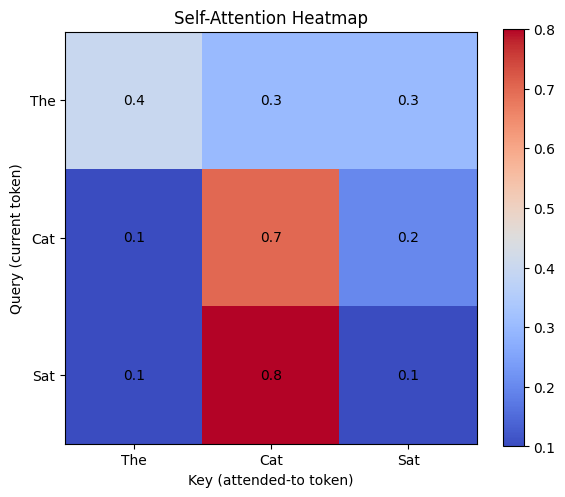

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Attention matrix
attention = np.array([
    [0.4, 0.3, 0.3],
    [0.1, 0.7, 0.2],
    [0.1, 0.8, 0.1]
])

tokens = ["The", "Cat", "Sat"]

# Create figure
fig, ax = plt.subplots(figsize=(6, 5))

# Heatmap
heatmap = ax.imshow(attention, cmap='coolwarm')

# Axis labels
ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))

ax.set_xticklabels(tokens)
ax.set_yticklabels(tokens)

ax.set_xlabel("Key (attended-to token)")
ax.set_ylabel("Query (current token)")
ax.set_title("Self-Attention Heatmap")

# Display values inside cells
for i in range(attention.shape[0]):
    for j in range(attention.shape[1]):
        ax.text(
            j,
            i,
            f"{attention[i, j]:.1f}",
            ha="center",
            va="center"
        )

# Color scale
fig.colorbar(heatmap, ax=ax)

plt.tight_layout()
plt.show()

Hotter (red) cells indicate stronger attention.

In practice, transformer researchers spend a lot of time looking at these heatmaps.


---

## 2.5 Manual Example with Numbers

Let's forget language for a moment.

Suppose each token contains one numerical value:

```python
tokens = [10, 20, 30]
```

Assume attention weights for the third token are:

```python
weights = [0.1, 0.8, 0.1]
```

The new representation becomes:

```python
0.1 * 10 +
0.8 * 20 +
0.1 * 30
```

Result:

```python
19
```

Notice:

* Output is not one token.
* Output is a weighted combination of all tokens.

This is exactly what self-attention does with vectors.

---

In [6]:
tokens = [5, 10, 50]

weights = [0.2, 0.3, 0.5]

result = sum(
    t * w
    for t, w in zip(tokens, weights)
)

print(result)

29.0



---

## 2.6 Why Is It Called Self-Attention?

Because:

* Queries come from the sentence itself.
* Keys come from the sentence itself.
* Values come from the sentence itself.

Everything attends to everything inside the same sequence.

```text
Sentence
   ↓
Attention
   ↓
Same Sentence
```

Contrast this with machine translation:

```text
French sentence
        ↓
attention
        ↓
English sentence
```

That is often called **cross-attention**.

We'll focus on self-attention first because it is the fundamental building block of transformers.

---

## Mental Model

A useful way to think about self-attention is:

```text
Every word gets a chance
to look at every other word
and decide how much information
it wants to borrow.
```

The output is:

```text
new word representation
=
weighted combination
of all word representations
```

---

## Key Takeaways

* Attention is a weighted information lookup.
* Every token can access every other token directly.
* Attention weights represent importance.
* Attention matrices describe all token-to-token interactions.
* Rows sum to 1 because they represent distributions.
* The output is a weighted combination of information from multiple tokens.

---

# Section 3 - Mathematical Foundations of Self-Attention

## Learning Objectives

By the end of this section, you should be able to:

* Understand dot product as a similarity measure
* Understand why similarity becomes attention “score”
* Understand softmax as normalization into probabilities
* Compute a basic attention step numerically
* Understand why attention is fundamentally “similarity + normalization + weighted sum”

---


## 3.1 From Intuition → Math

In Section 2, we said:

> Each word assigns importance weights to other words.

Now the question is:

> How do we compute those weights automatically?

We need a function that:

* compares words
* produces a score
* converts scores into probabilities

This is exactly what attention does.

---

## 3.2 Dot Product = Similarity

The simplest way to compare two vectors is:

$
a \cdot b = \sum_i a_i b_i
$

**Intuition**

* If two vectors point in the same direction → large value
* If they are unrelated → small value
* If opposite → negative value

---

### Example

Let’s define two toy word vectors:

```text id="x8qk9c"
cat = [1, 0]
sat = [0.9, 0.1]
table = [0, 1]
```

Now compute similarity:

```text id="q9p1md"
cat · sat  ≈ high
cat · table ≈ low
```

So:

> "cat" is more similar to "sat" than to "table"

---

### Key Insight

Attention is built on:

> similarity determines importance

---


## 3.3 From Similarity to Scores

We define:

$
score(q,k)=q \cdot k
$

Where:

* **q (query)** = what I’m looking for
* **k (key)** = what I contain

---

### Interpretation

If:

```text id="h3kq9d"
query = "sat"
key = "cat"
```

Then:

> high score → strong relevance

---



## 3.4 Why We Need Softmax

Raw dot products can be:

* negative
* unbounded
* inconsistent across tokens

We need to convert them into probabilities.

That’s what softmax does.

---

### Softmax Function

$
\text{softmax}(x_i)=\frac{e^{x_i}}{\sum_j e^{x_j}}
$

---

### What It Does (Intuition)

Softmax:

* turns numbers into probabilities
* ensures sum = 1
* amplifies differences

Example:

```text id="m1q8wx"
[2.0, 1.0, 0.1]
```

becomes:

```text id="n8k2zq"
[0.66, 0.24, 0.10]
```

---

### Why exponential?

Because it:

* makes big values dominate
* keeps everything positive
* increases contrast

---



## 3.5 Putting It Together

Now we combine:

**Step 1: similarity**

$
QK^T
$

**Step 2: normalize**

$
\text{softmax}(QK^T)
$

**Step 3: weighted sum**

We apply weights to values (V).

---

## 3.6 Full Attention Formula

Now we can write the full mechanism:

$
\text{Attention}(Q,K,V)=\text{softmax}(QK^T)V
$

---

### Interpretation in Plain English

1. Compare each word to every other word
2. Convert comparisons into probabilities
3. Use probabilities to mix information

---


## 3.7 Tiny Manual Example

In [ ]:
import numpy as np

# Step 1: Scores
scores = np.array([2.0, 1.0, 0.1])

# Step 2: Softmax
exp_scores = np.exp(scores)
weights = exp_scores / exp_scores.sum()

print(weights)

# Step 3: Weighted Sum
values = np.array([10, 20, 30])

output = (weights * values).sum()

print(output)

[0.65900114 0.24243297 0.09856589]
14.395647515233502


The output is:

> a mixture of all values, weighted by importance

## 3.8 Why This Works So Well

Attention works because:

* similarity captures meaning
* softmax creates competition
* weighted sum preserves information

So instead of:

```text id="k3m9qp"
compress everything → lose information
```

we do:

```text id="z8w1na"
selectively combine → preserve relevant information
```

---

## Key Takeaways

* Dot product measures similarity
* Similarity becomes attention score
* Softmax converts scores into probabilities
* Attention = weighted mixing of information
* Everything reduces to:
  **compare → normalize → combine**

---


# Section 4 - Query, Key, Value (Q, K, V)

## Learning Objectives

After this section, you should be able to:

* Understand what Q, K, V represent intuitively
* Understand why we need 3 different projections
* Understand how Q, K, V are learned
* Map Q/K/V to real-world retrieval systems
* See attention as a “learned search engine”

---



## 4.1 The Big Idea (Before Math)

Self-attention is basically:

> “For each word, find relevant words and pull information from them.”

To do this, every word needs 3 roles:

| Role      | Meaning                     |
| --------- | --------------------------- |
| Query (Q) | What am I looking for?      |
| Key (K)   | What do I contain?          |
| Value (V) | What information do I give? |

---

### Library Analogy (Very Important)

Imagine a library:

* **Query** = your search request
* **Key** = book index / catalog description
* **Value** = actual book content

So:

> You match Query ↔ Key
> Then retrieve Value

---



## 4.2 Why Do We Need Three Different Vectors?

A natural question:

> Why not just use embeddings directly?

Because we need separation of concerns:

**If we used only one vector:**

* same representation used for matching and information
* too restrictive
* cannot specialize behavior

---

**Instead we separate:**

**Key (matching identity)**

* used for similarity comparison
* “what am I about?”

**Query (search intent)**

* “what am I looking for?”

**Value (content)**

* “what information do I provide?”

---



## 4.3 How Q, K, V Are Created

Each token embedding is transformed using learned matrices:

$
Q = XW_Q,\quad K = XW_K,\quad V = XW_V
$

Where:

* $X$ = input embeddings
* $W_Q$, $W_K$, $W_V$ = learned weight matrices

---

**Key Insight**

We are not manually designing Q/K/V.

We are learning them.

---



## 4.4 What This Means Intuitively

Each word gets transformed into:

 1. Query version

> what I am searching for in the sentence

 2. Key version

> how I should be matched by others

 3. Value version

> what information I contribute if selected

---

**Example: “sat”**

For the word:

```text id="q9x1lm"
sat
```

It might learn:

* Query: looking for subject (who is doing action?)
* Key: signals “I am an action verb”
* Value: carries semantic meaning of action

---



## 4.5 Attention as a Retrieval System

Now we can rewrite attention conceptually:

Step 1: Matching

$
\text{similarity}(Q, K) = QK^T
$

Step 2: Normalize

$
A = \text{softmax}(QK^T)
$

Step 3: Retrieve information

$
\text{Output} = AV
$

---

**Interpretation**

* A = “how much I pay attention”
* V = “what I actually take from others”

---


## 4.6 Important Insight

Notice:

> Q and K decide *where to look*
> V decides *what you get*

This separation is critical.

---

### Analogy: Google Search

| Component | Analogy                |
| --------- | ---------------------- |
| Query     | your search text       |
| Key       | indexed metadata       |
| Value     | actual webpage content |

---



## 4.7 Why Learnable Projections Matter

Without W matrices:

* all words treated the same way
* no specialization

With W matrices:

* model learns what to match
* learns what to extract
* adapts per task

---

Self-attention is not fixed logic.

It is:

> a learned retrieval system

---

## 4.8 Tiny Numerical Example

In [21]:
X = np.array([
    [1, 0],  # word A
    [0, 1],  # word B
])

# Projection matrices:
W_Q = np.array([[2, 1],
                [1, 2]])

W_K = np.array([[2, 1],
                [1, 2]])

W_V = np.array([[10, 1],
                [1, 10]])

In [22]:
# Compute:
Q = X @ W_Q
K = X @ W_K
V = X @ W_V

Q, K, V

(array([[2, 1],
        [1, 2]]),
 array([[2, 1],
        [1, 2]]),
 array([[10,  1],
        [ 1, 10]]))

In [23]:
scores = Q @ K.T
weights = np.exp(scores) / np.exp(scores).sum(axis=1, keepdims=True)
output = weights @ V
scores, weights, output

(array([[5, 4],
        [4, 5]]),
 array([[0.73105858, 0.26894142],
        [0.26894142, 0.73105858]]),
 array([[7.57952721, 3.42047279],
        [3.42047279, 7.57952721]]))

## 4.9 Key Conceptual Shift

Before:

> “We compute attention weights somehow”

Now:

> “We *learn* how to compute attention weights”

That’s the breakthrough.

---

## Key Takeaways

* Q = what I’m looking for
* K = what I offer for matching
* V = what information I provide
* Q/K/V are learned transformations of embeddings
* Attention is a learned retrieval system
* Separation of Q, K, V is what makes transformers powerful

---

# Section 5 - Full Self-Attention Step-by-Step

## Learning Objectives

After this section, you should be able to:

* Manually compute self-attention end-to-end
* Understand each matrix operation in practice
* See how Q, K, V interact numerically
* Understand why attention is just linear algebra + softmax
* Connect intuition → implementation

---



## 5.1 Toy Sentence

We will use a 3-token sentence:

```text id="s1"
dog chased ball
```

We assign simple 2D embeddings:

In [28]:
import numpy as np

X = np.array([
    [1.0, 0.0],  # cat
    [0.5, 1.0],  # sees
    [0.0, 1.0],  # dog
])

tokens = ["cat", "sees", "dog"]

## 5.2 Define Q, K, V

Instead of just using identity matrices, we introduce slight transformations

In [29]:
W_Q = np.array([
    [1, 0],
    [0, 1]
])

W_K = np.array([
    [0.8, 0.2],
    [0.2, 0.8]
])

W_V = np.array([
    [1, 0],
    [0, 1]
])

### Compute Q, K, V

In [30]:
Q = X @ W_Q
K = X @ W_K
V = X @ W_V

print("Q:\n", Q)
print("K:\n", K)
print("V:\n", V)

Q:
 [[1.  0. ]
 [0.5 1. ]
 [0.  1. ]]
K:
 [[0.8 0.2]
 [0.6 0.9]
 [0.2 0.8]]
V:
 [[1.  0. ]
 [0.5 1. ]
 [0.  1. ]]


So:

* Q = K = V = X

This removes noise so we can focus on mechanics.


## 5.3 Compute Attention Scores

$
QK^T
$

In [31]:
scores = Q @ K.T

print("Scores:\n", scores)

Scores:
 [[0.8 0.6 0.2]
 [0.6 1.2 0.9]
 [0.2 0.9 0.8]]


**Interpretation**

Each row = one token asking:

> “How much should I attend to every other token?”

---


## 5.4 Apply Softmax Row-wise

Now we normalize each row:

$
\text{softmax}(x_i)=\frac{e^{x_i}}{\sum_j e^{x_j}}
$



In [32]:
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))  # stability trick
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

attention = softmax(scores)

print("Attention weights:\n", attention)

Attention weights:
 [[0.42237892 0.34581461 0.23180647]
 [0.23969448 0.43675182 0.3235537 ]
 [0.20678796 0.41641981 0.37679223]]


## 5.5 Compute Final Output

$
AV
$

In [33]:
output = attention @ V

print("Output:\n", output)

Output:
 [[0.59528623 0.57762108]
 [0.45807039 0.76030552]
 [0.41499787 0.79321204]]


## 5.6 Full End-to-End Code

In [34]:
import numpy as np

# -----------------------
# 1. Input embeddings
# -----------------------
X = np.array([
    [1.0, 0.0],  # cat
    [0.5, 1.0],  # sees
    [0.0, 1.0],  # dog
])

tokens = ["cat", "sees", "dog"]

# -----------------------
# 2. Projection matrices
# -----------------------
W_Q = np.array([
    [1, 0],
    [0, 1]
])

W_K = np.array([
    [0.8, 0.2],
    [0.2, 0.8]
])

W_V = np.array([
    [1, 0],
    [0, 1]
])

# -----------------------
# 3. Compute Q, K, V
# -----------------------
Q = X @ W_Q
K = X @ W_K
V = X @ W_V

# -----------------------
# 4. Attention scores
# -----------------------
scores = Q @ K.T

# -----------------------
# 5. Softmax
# -----------------------
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

attention = softmax(scores)

# -----------------------
# 6. Output
# -----------------------
output = attention @ V

# -----------------------
# 7. Display
# -----------------------
np.set_printoptions(precision=3, suppress=True)

print("Tokens:", tokens)
print("\nX:\n", X)
print("\nQ:\n", Q)
print("\nK:\n", K)
print("\nV:\n", V)
print("\nScores:\n", scores)
print("\nAttention:\n", attention)
print("\nOutput:\n", output)

Tokens: ['cat', 'sees', 'dog']

X:
 [[1.  0. ]
 [0.5 1. ]
 [0.  1. ]]

Q:
 [[1.  0. ]
 [0.5 1. ]
 [0.  1. ]]

K:
 [[0.8 0.2]
 [0.6 0.9]
 [0.2 0.8]]

V:
 [[1.  0. ]
 [0.5 1. ]
 [0.  1. ]]

Scores:
 [[0.8 0.6 0.2]
 [0.6 1.2 0.9]
 [0.2 0.9 0.8]]

Attention:
 [[0.422 0.346 0.232]
 [0.24  0.437 0.324]
 [0.207 0.416 0.377]]

Output:
 [[0.595 0.578]
 [0.458 0.76 ]
 [0.415 0.793]]


## 5.7 Observations

When you run it:

1. Scores matrix

You’ll see:

* similarity between “cat ↔ sees”
* similarity between “sees ↔ dog”

---

2. Attention matrix

Each row:

* sums to 1
* shows “who each word listens to”

---

3. Output vectors

Each word becomes:

> a mixture of other words

---

## 5.8 Key Insight

Even with this tiny model:

> meaning emerges from weighted mixing of token representations

No rules.
No grammar engine.
Just:

* geometry (dot products)
* normalization (softmax)
* mixing (matrix multiplication)


# Section 6 - Why We Scale by √dₖ

## Learning Objectives

After this section, you should be able to:

* Understand why dot products grow with dimension
* Understand why softmax becomes unstable
* Understand what “softmax saturation” means
* Understand the purpose of scaling in attention
* See why √dₖ is not arbitrary, but mathematically motivated

---


## 6.1 The Problem We Are Trying to Solve

Recall attention scores:

$
QK^T
$

This is just dot products between vectors.

---

### The hidden problem

If vectors have dimension (d), then:

> dot product magnitude grows with (d)

So as embeddings get larger:

* scores become larger
* differences become extreme
* softmax becomes unstable

---



## 6.2 Why dot products grow

Assume:

* components are random with mean 0
* variance 1

Then:

$
\mathbb{E}[q \cdot k] \propto d
$

So:

> more dimensions → larger variance of scores

---



## 6.3 What goes wrong in softmax

Softmax:

$
\text{softmax}(x_i)=\frac{e^{x_i}}{\sum_j e^{x_j}}
$

**Problem:**

If scores are large:

Example:

```text id="x1"
[10, 9, 8]
```

Softmax becomes:

```text id="x2"
[0.84, 0.11, 0.05]
```

Now even stronger case:

```text id="x3"
[100, 90, 80]
```

Softmax becomes:

```text id="x4"
[~1.0, ~0.0, ~0.0]
```

---

**This is called:**

> Softmax saturation

---


## 6.4 Why saturation is bad

When softmax saturates:

* gradients become tiny
* model stops learning meaningful distinctions
* attention becomes “hard selection” too early

So instead of:

> learning smooth relationships

we get:

> winner-takes-all collapse

---



## 6.5 The Fix: Scaling

We fix this by scaling dot products:

$
\frac{QK^T}{\sqrt{d_k}}
$

---

### Why √dₖ specifically?

Because:

* variance of dot product grows ~ dₖ
* dividing by √dₖ normalizes variance

So:

> scaled scores stay roughly stable across dimensions

---

## 6.6 Intuition

Think of it like this:

**Without scaling:**

* increasing embedding size = louder and louder scores
* softmax becomes overconfident

**With scaling:**

* scores stay in a controlled range
* softmax remains smooth and trainable

---



## 6.7 Numerical Demo (CODE)

In [35]:
import numpy as np

np.set_printoptions(precision=3, suppress=True)

def softmax(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x)

# simulate increasing dimension effect
def simulate(d, trials=5):
    print(f"\n--- dimension d={d} ---")
    
    for t in range(trials):
        q = np.random.randn(d)
        k = np.random.randn(d)
        
        score = np.dot(q, k)
        scaled_score = score / np.sqrt(d)
        
        print(f"raw: {score:.3f} | scaled: {scaled_score:.3f}")

simulate(2)
simulate(10)
simulate(50)
simulate(200)


--- dimension d=2 ---
raw: -0.520 | scaled: -0.368
raw: 0.332 | scaled: 0.235
raw: 0.487 | scaled: 0.344
raw: -0.264 | scaled: -0.187
raw: 1.190 | scaled: 0.841

--- dimension d=10 ---
raw: 1.780 | scaled: 0.563
raw: 1.131 | scaled: 0.358
raw: -2.268 | scaled: -0.717
raw: -0.978 | scaled: -0.309
raw: 1.305 | scaled: 0.413

--- dimension d=50 ---
raw: -3.638 | scaled: -0.514
raw: -1.684 | scaled: -0.238
raw: -1.961 | scaled: -0.277
raw: 4.027 | scaled: 0.570
raw: -6.631 | scaled: -0.938

--- dimension d=200 ---
raw: -8.324 | scaled: -0.589
raw: -2.399 | scaled: -0.170
raw: -3.644 | scaled: -0.258
raw: 15.414 | scaled: 1.090
raw: -13.637 | scaled: -0.964



**Observations**

As dimension increases:

**Raw scores:**

* grow in magnitude
* become unstable

**Scaled scores:**

* stay roughly similar range
* more consistent behavior


## 6.8 Softmax Behavior Demo

In [36]:
import numpy as np

def softmax(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x)

x_small = np.array([2, 1, 0])
x_large = np.array([20, 10, 0])

print("softmax small:", softmax(x_small))
print("softmax large:", softmax(x_large))

softmax small: [0.665 0.245 0.09 ]
softmax large: [1. 0. 0.]



## 6.9 Final Attention Formula (Correct Version)

Now we finally have the real transformer equation:

$
\text{Attention}(Q,K,V)=\text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$

---

**Key Takeaways**

* Dot products grow with vector dimension
* Softmax becomes unstable when inputs are large
* Without scaling, attention collapses to extreme values
* √dₖ keeps variance stable
* This is critical for deep transformer training

---

**Mental Model**

> Scaling is not a trick — it is variance control for stable learning

---

# Conclusion

In this notebook, we explored the foundations of self-attention and developed an understanding of how Transformer models process information.

We started by examining the limitations of recurrent neural networks and the challenges of modeling long-range dependencies. This motivated the introduction of attention mechanisms, which allow tokens to access information from any other token in a sequence directly.

We then developed the core intuition behind self-attention:

> Each token determines which other tokens are most relevant and combines information from them using learned attention weights.

To understand how these weights are computed, we introduced several fundamental concepts:

* Dot products as a measure of similarity.
* Softmax as a mechanism for converting similarity scores into probability distributions.
* Attention matrices as representations of token-to-token interactions.
* Query, Key, and Value vectors as specialized representations used for matching and information retrieval.

We also worked through complete numerical examples and observed how attention outputs are formed as weighted combinations of value vectors.

Finally, we introduced scaled dot-product attention and learned why the scaling factor √dₖ is required to maintain stable score distributions and prevent softmax saturation in higher-dimensional spaces.

The central idea of self-attention can be summarized as:

1. Compare tokens using Query and Key vectors.
2. Convert similarities into attention weights using Softmax.
3. Use those weights to combine Value vectors.
4. Produce context-aware token representations.

The resulting attention mechanism is expressed by the following formula:

$
\text{Attention}(Q,K,V)=\text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$

This formula is the foundation upon which modern Transformer architectures are built.

In the [next notebook](https://github.com/Maxstef/data-loves-ml-for-people-course/blob/main/notebooks/4_3_dl_sequence_modeling/0_5_self_attention_scratch.ipynb), we will move from theory to implementation by building a complete self-attention layer from scratch and exploring how attention is implemented in real machine learning systems.
